<a href="https://colab.research.google.com/github/vaidiknakrani/parul_AI_ML_Learning/blob/main/day_1_titanic_survival_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 1 - Notebook 2: Predicting Titanic Survival with Logistic Regression

**Parul University & TelcoLearn | AI-ML Training Program 2027**  
**Day 1 | July 13, 2025 | 2:30 PM - 4:00 PM**

---

## Objective
Build a binary classifier to predict who survived the Titanic.

| Step | What you do | What you learn |
|------|-------------|----------------|
| 1 | Load and inspect data | Missing values, data types |
| 2 | Handle missing values | Median/mode imputation |
| 3 | Encode categoricals | Sex, Embarked |
| 4 | Train LogisticRegression | Sigmoid, log-loss |
| 5 | Evaluate metrics | Accuracy, F1, AUC, log-loss |
| 6 | Sigmoid curve + confusion matrix | Visual understanding |
| 7 | Threshold experiment | 0.5 is not always optimal |

**Dataset:** Titanic - Machine Learning from Disaster (Kaggle)  
**Task:** Predict `Survived` (0 = No, 1 = Yes)  
**Class split:** ~38% survived, ~62% did not

In [ ]:
import os
import time
import psutil

process = psutil.Process(os.getpid())
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (accuracy_score, log_loss, f1_score,
                                     classification_report, confusion_matrix,
                                     ConfusionMatrixDisplay, roc_auc_score,
                                     roc_curve, precision_score, recall_score)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful.')

All imports successful.


In [ ]:
DATASET_PATH = '/kaggle/input/competitions/titanic'
# DATASET_PATH = '.'  # uncomment for local run

train = pd.read_csv(f'/kaggle/input/competitions/titanic/train.csv')
test  = pd.read_csv(f'/kaggle/input/competitions/titanic/test.csv')

print(f'Train: {train.shape}   Test: {test.shape}')
print(f'Survival rate: {train["Survived"].mean()*100:.1f}%  '
      f'({train["Survived"].sum()} survived out of {len(train)})')
print()
display(train.head())

Train: (891, 12)   Test: (418, 11)
Survival rate: 38.4%  (342 survived out of 891)



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Missing value overview
print('=== Missing Values (train) ===')
missing = train.isnull().sum()
print(pd.DataFrame({'count': missing, 'pct_%': (missing/len(train)*100).round(1)})[missing>0])

=== Missing Values (train) ===
          count  pct_%
Age         177   19.9
Cabin       687   77.1
Embarked      2    0.2


## Section 2 - Data Cleaning and Feature Engineering

**Missing value strategy:**
- `Age` (20% missing): fill with median age from training set
- `Embarked` (0.2% missing): fill with mode (most common port = 'S')
- `Cabin` (77% missing): too sparse - drop

**Why these features?** Women and children had priority access to lifeboats;
1st-class passengers had better access. Port of embarkation reflects socioeconomic status.

In [ ]:
def preprocess(df, fit_data=None):
    df  = df.copy()
    ref = fit_data if fit_data is not None else df

    # Fill missing values using TRAINING statistics
    df['Age'].fillna(ref['Age'].median(), inplace=True)
    df['Embarked'].fillna(ref['Embarked'].mode()[0], inplace=True)
    df['Fare'].fillna(ref['Fare'].median(), inplace=True)

    # Encode Sex: female=1, male=0
    df['Sex_enc'] = (df['Sex'] == 'female').astype(int)

    # Encode Embarked: S=0, C=1, Q=2
    df['Embarked_enc'] = df['Embarked'].map({'S':0,'C':1,'Q':2}).fillna(0).astype(int)

    # Feature engineering
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
    df['AgeBin']     = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                              labels=[0,1,2,3,4]).astype(float)
    return df

train_proc = preprocess(train)
test_proc  = preprocess(test, fit_data=train)

print('Preprocessing done. Missing values remaining:')
key_cols = ['Age','Embarked','Fare','Sex_enc','Embarked_enc']
print(train_proc[key_cols].isnull().sum())

Preprocessing done. Missing values remaining:
Age             0
Embarked        0
Fare            0
Sex_enc         0
Embarked_enc    0
dtype: int64


In [ ]:
FEATURES = ['Pclass','Sex_enc','Age','Fare','Embarked_enc',
            'FamilySize','IsAlone','AgeBin']
TARGET   = 'Survived'

X = train_proc[FEATURES].values
y = train_proc[TARGET].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}')
print(f'Survival rate in train: {y_train.mean()*100:.1f}%')

Train: 712  Val: 179
Survival rate in train: 38.3%


In [ ]:
cpu_before = psutil.cpu_percent(interval=1)
memory_before = process.memory_info().rss / (1024**2)

training_start = time.time()

print("="*50)
print("Training Started")
print("="*50)
print(f"CPU Before Training : {cpu_before:.2f}%")
print(f"Memory Before Training : {memory_before:.2f} MB")

Training Started
CPU Before Training : 0.70%
Memory Before Training : 251.88 MB


## Section 3 - Train Logistic Regression

Logistic regression applies the **sigmoid** to the linear score:

  P(survived=1 | x) = sigma(theta.T @ x) = 1 / (1 + exp(-theta.T @ x))

Training minimises **log-loss** (binary cross-entropy), which is convex for this model.

In [ ]:
lr = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

training_end = time.time()
training_time = training_end - training_start

cpu_after = psutil.cpu_percent(interval=1)
memory_after = process.memory_info().rss / (1024**2)

prediction_start = time.time()

y_pred_val = lr.predict(X_val)
y_pred_prob = lr.predict_proba(X_val)[:, 1]

prediction_end = time.time()
prediction_time = prediction_end - prediction_start

print("=" * 50)
print(f"Training Time : {training_time:.4f} sec")
print(f"Prediction Time : {prediction_time:.6f} sec")
print(f"CPU Usage : {cpu_after:.2f}%")
print(f"Memory Usage : {memory_after:.2f} MB")
print("=" * 50)

Training Time : 19.9689 sec
Prediction Time : 0.000868 sec
CPU Usage : 9.50%
Memory Usage : 251.88 MB


## Section 4 - Evaluation Metrics

| Metric | Formula | When to use |
|--------|---------|-------------|
| Accuracy | (TP+TN)/N | Balanced classes only |
| Log-Loss | -mean[y*log(p) + (1-y)*log(1-p)] | Penalises confident errors |
| Precision | TP/(TP+FP) | Minimise false positives |
| Recall | TP/(TP+FN) | Minimise false negatives |
| F1 | 2*P*R/(P+R) | Balance precision and recall |
| AUC-ROC | Area under ROC | Threshold-independent |

In [ ]:
acc     = accuracy_score(y_val, y_pred_val)
logloss = log_loss(y_val, y_prob_val)
f1      = f1_score(y_val, y_pred_val)
auc     = roc_auc_score(y_val, y_prob_val)

print('=' * 45)
print('   EVALUATION METRICS (Validation Set)')
print('=' * 45)
print(f'   Accuracy : {acc*100:>6.2f}%')
print(f'   Log-Loss : {logloss:>8.4f}  (lower=better)')
print(f'   F1 Score : {f1:>8.4f}  (higher=better)')
print(f'   AUC-ROC  : {auc:>8.4f}  (higher=better)')
print('=' * 45)
print()
print(classification_report(y_val, y_pred_val,
      target_names=['Did not survive', 'Survived']))

   EVALUATION METRICS (Validation Set)
   Accuracy :  79.89%
   Log-Loss :   0.4517  (lower=better)
   F1 Score :   0.7273  (higher=better)
   AUC-ROC  :   0.8494  (higher=better)

                 precision    recall  f1-score   support

Did not survive       0.82      0.86      0.84       110
       Survived       0.76      0.70      0.73        69

       accuracy                           0.80       179
      macro avg       0.79      0.78      0.78       179
   weighted avg       0.80      0.80      0.80       179



## Section 5 - Sigmoid Curve and Probability Distribution

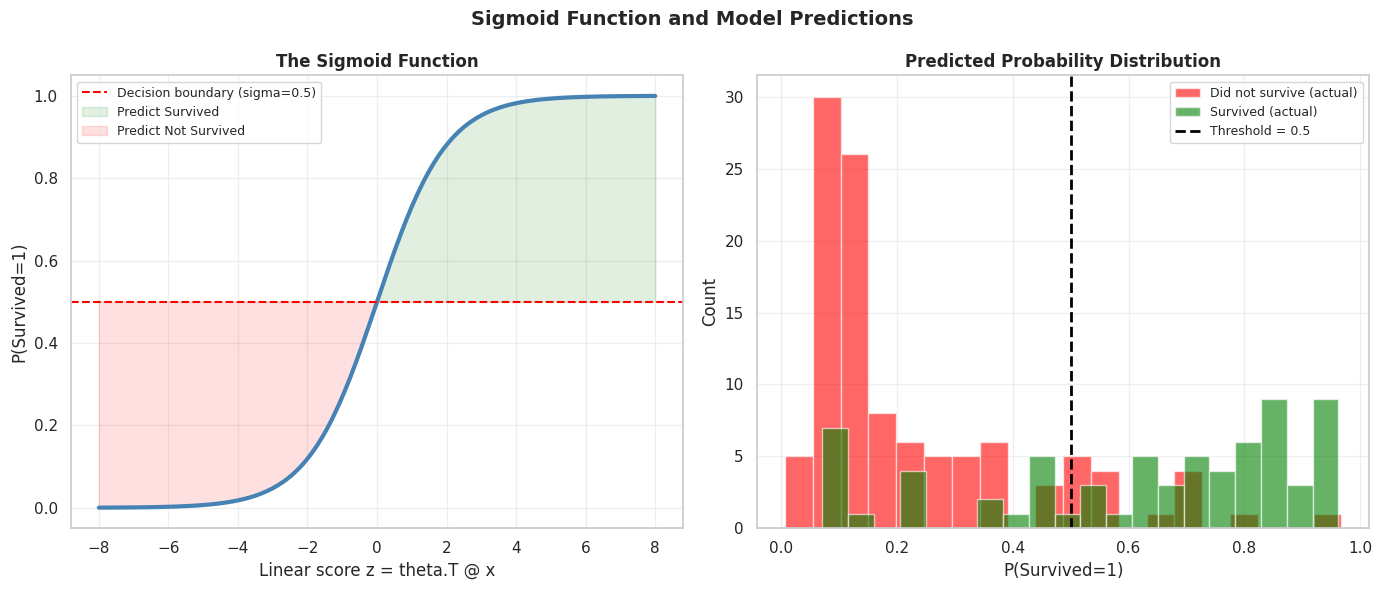

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sigmoid function
z = np.linspace(-8, 8, 200)
sigma = 1 / (1 + np.exp(-z))
axes[0].plot(z, sigma, 'steelblue', linewidth=3)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1.5,
                label='Decision boundary (sigma=0.5)')
axes[0].fill_between(z, sigma, 0.5, where=(sigma>0.5), alpha=0.12,
                     color='green', label='Predict Survived')
axes[0].fill_between(z, sigma, 0.5, where=(sigma<0.5), alpha=0.12,
                     color='red', label='Predict Not Survived')
axes[0].set_xlabel('Linear score z = theta.T @ x'); axes[0].set_ylabel('P(Survived=1)')
axes[0].set_title('The Sigmoid Function', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Predicted probability distribution
axes[1].hist(y_prob_val[y_val==0], bins=20, color='red', alpha=0.6,
             label='Did not survive (actual)', edgecolor='white')
axes[1].hist(y_prob_val[y_val==1], bins=20, color='green', alpha=0.6,
             label='Survived (actual)', edgecolor='white')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2,
                label='Threshold = 0.5')
axes[1].set_xlabel('P(Survived=1)'); axes[1].set_ylabel('Count')
axes[1].set_title('Predicted Probability Distribution', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Sigmoid Function and Model Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 6 - Confusion Matrix and ROC Curve

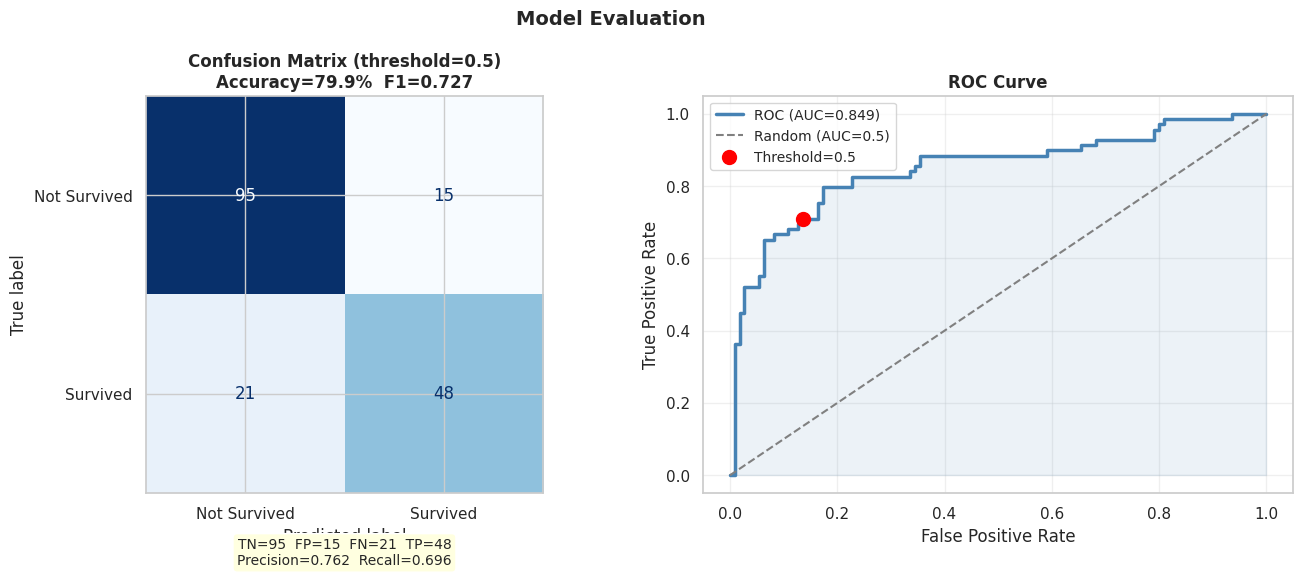

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Survived','Survived'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
tn, fp, fn, tp = cm.ravel()
axes[0].set_title(f'Confusion Matrix (threshold=0.5)\n'
                  f'Accuracy={acc*100:.1f}%  F1={f1:.3f}', fontweight='bold')
axes[0].text(0.5, -0.18,
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}\n'
    f'Precision={precision_score(y_val,y_pred_val):.3f}  '
    f'Recall={recall_score(y_val,y_pred_val):.3f}',
    transform=axes[0].transAxes, ha='center', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='lightyellow'))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob_val)
axes[1].plot(fpr, tpr, 'steelblue', linewidth=2.5, label=f'ROC (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1], 'gray', linestyle='--', linewidth=1.5, label='Random (AUC=0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
idx = np.argmin(np.abs(thresholds - 0.5))
axes[1].scatter(fpr[idx], tpr[idx], s=100, color='red', zorder=5,
                label=f'Threshold=0.5')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 7 - Decision Threshold Experiment

The default threshold **0.5** is not always optimal.

- **Lower threshold (0.3)**: more people predicted to survive, higher recall, lower precision
- **Higher threshold (0.7)**: fewer predicted to survive, higher precision, lower recall

A rescue coordinator (minimise missed survivors) would prefer **lower threshold**.  
A historian verifying records (minimise false positives) would prefer **higher threshold**.

In [ ]:
# Compute metrics across thresholds
threshold_range = np.arange(0.1, 0.91, 0.02)
rows = []
for t in threshold_range:
    preds = (y_prob_val >= t).astype(int)
    if 0 < preds.sum() < len(preds):
        rows.append({
            'threshold': t,
            'accuracy' : accuracy_score(y_val, preds),
            'precision': precision_score(y_val, preds, zero_division=0),
            'recall'   : recall_score(y_val, preds, zero_division=0),
            'f1'       : f1_score(y_val, preds, zero_division=0)
        })

df_thresh = pd.DataFrame(rows)

print('Metrics at key thresholds:')
print(f"{'Threshold':>10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>8}")
print('-' * 55)
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    mask = (df_thresh['threshold'] - t).abs() < 0.015
    if mask.any():
        r = df_thresh[mask].iloc[0]
        marker = ' <-- default' if abs(t-0.5) < 0.01 else ''
        print(f"  {t:>8.1f}   {r['accuracy']:>9.3f}   {r['precision']:>9.3f}  "
              f"{r['recall']:>9.3f}  {r['f1']:>7.3f}{marker}")

Metrics at key thresholds:
 Threshold   Accuracy  Precision     Recall       F1
-------------------------------------------------------
       0.3       0.777       0.671      0.826    0.740
       0.4       0.816       0.743      0.797    0.769
       0.5       0.799       0.762      0.696    0.727 <-- default
       0.6       0.821       0.863      0.638    0.733
       0.7       0.793       0.900      0.522    0.661


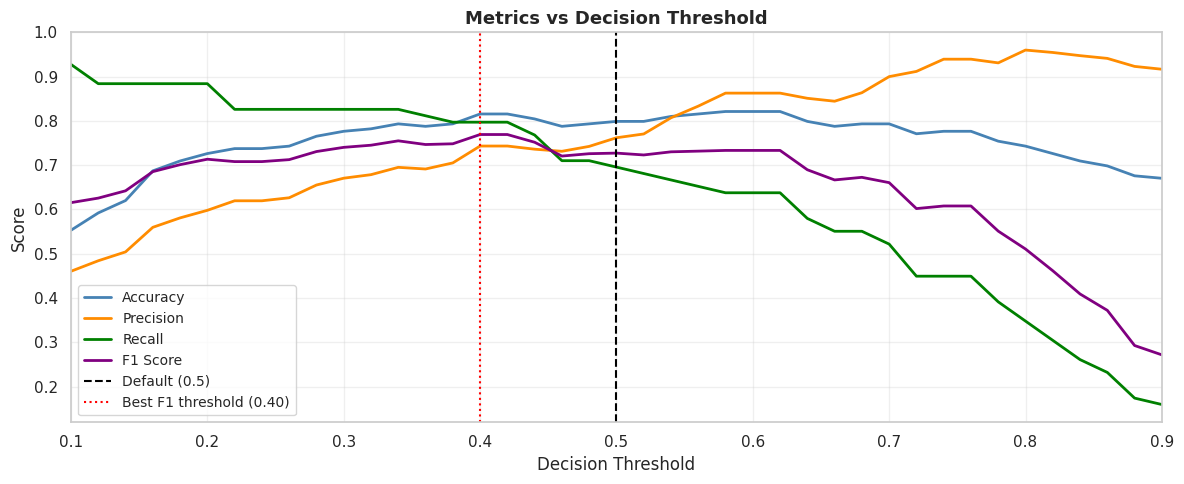

Best F1 threshold: 0.40


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for col, color, label in [
    ('accuracy',  'steelblue',  'Accuracy'),
    ('precision', 'darkorange', 'Precision'),
    ('recall',    'green',      'Recall'),
    ('f1',        'purple',     'F1 Score'),
]:
    ax.plot(df_thresh['threshold'], df_thresh[col],
            color=color, linewidth=2, label=label)

ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Default (0.5)')
best_f1_t = df_thresh.loc[df_thresh['f1'].idxmax(), 'threshold']
ax.axvline(best_f1_t, color='red', linestyle=':', linewidth=1.5,
           label=f'Best F1 threshold ({best_f1_t:.2f})')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Metrics vs Decision Threshold', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(0.1, 0.9)
plt.tight_layout()
plt.show()

print(f'Best F1 threshold: {best_f1_t:.2f}')

## Section 8 - Feature Importance via Coefficients

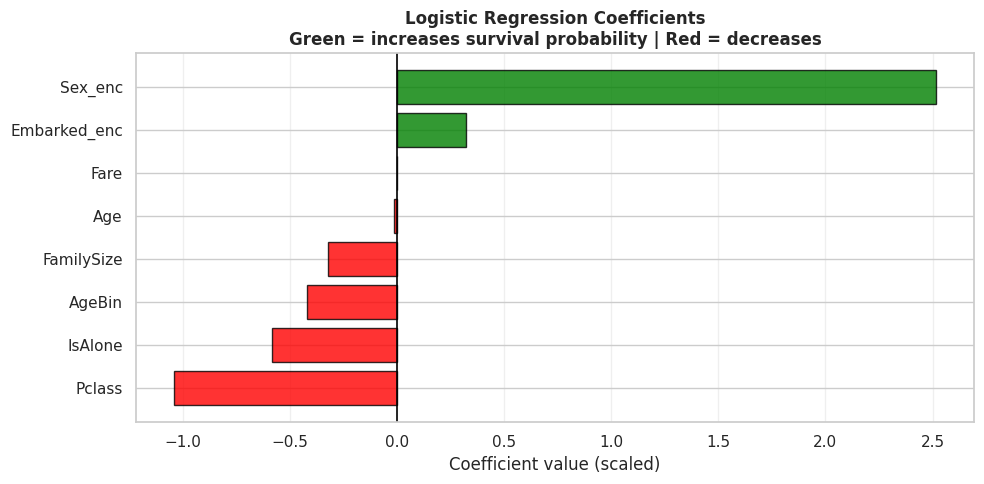

Interpretation:
  Sex_enc (+):   Female had much higher survival (women and children first)
  Pclass (-):    3rd class had lower survival rate
  Age (-):       Older passengers survived at lower rates
  Fare (+):      Higher fare = better cabin = better lifeboat access


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
coefs = pd.Series(lr.coef_[0], index=FEATURES).sort_values()
colors = ['red' if c < 0 else 'green' for c in coefs.values]
ax.barh(coefs.index, coefs.values, color=colors, edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('Coefficient value (scaled)')
ax.set_title('Logistic Regression Coefficients\n'
             'Green = increases survival probability | Red = decreases',
             fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  Sex_enc (+):   Female had much higher survival (women and children first)')
print('  Pclass (-):    3rd class had lower survival rate')
print('  Age (-):       Older passengers survived at lower rates')
print('  Fare (+):      Higher fare = better cabin = better lifeboat access')

In [ ]:
import numpy as np

model_size = (
    lr.coef_.nbytes +
    np.array([lr.intercept_]).nbytes
) / (1024**2)

print("\n")
print("=" * 70)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 70)

print(f"{'Training Time':35}: {training_time:.4f} sec")
print(f"{'Prediction Time':35}: {prediction_time:.6f} sec")

print("-" * 70)

print(f"{'CPU Usage':35}: {cpu_after:.2f}%")
print(f"{'Memory Usage':35}: {memory_after:.2f} MB")

print("-" * 70)

print(f"{'Model Size':35}: {model_size:.6f} MB")

print("-" * 70)

print(f"{'Validation Accuracy':35}: {accuracy_score(y_val, y_pred_val):.4f}")
print(f"{'Precision':35}: {precision_score(y_val, y_pred_val):.4f}")
print(f"{'Recall':35}: {recall_score(y_val, y_pred_val):.4f}")
print(f"{'F1 Score':35}: {f1_score(y_val, y_pred_val):.4f}")
print(f"{'ROC-AUC':35}: {roc_auc_score(y_val, y_pred_prob):.4f}")

print("=" * 70)



FINAL PERFORMANCE SUMMARY
Training Time                      : 19.9689 sec
Prediction Time                    : 0.000868 sec
----------------------------------------------------------------------
CPU Usage                          : 9.50%
Memory Usage                       : 251.88 MB
----------------------------------------------------------------------
Model Size                         : 0.000069 MB
----------------------------------------------------------------------
Validation Accuracy                : 0.7989
Precision                          : 0.7619
Recall                             : 0.6957
F1 Score                           : 0.7273
ROC-AUC                            : 0.8490
